# Capacitated Plant Location with Discrete Capacity Tiers

**Problem.** An electronics company is planning a ten-year production footprint for a new tablet. Nine markets must be supplied every month. Seven candidate sites are available, and each site can host up to three separate plants, i.e. one low-capacity, one medium-capacity and one high-capacity, each with its own monthly fixed cost and its own output limit. A site may host any subset of the three, so capacity at a site is built up in discrete blocks rather than chosen from a menu. Producing one unit at site $i$ and delivering it to market $j$ costs a known amount.

This is a **facility location decision**: which plants to build, and which markets each one should supply, to minimise total cost. The notebook builds the base mixed-integer program and then answers three follow-up policy questions, each independent of the others:

| Variant | Policy question |
| --- | --- |
| **$\;\;\;\;\;$Base case** | No restrictions beyond capacity and demand |
| **(a) Min-one-plant** | Every site must host at least one plant |
| **(b) Max-two-sites** | At most two sites may be used (still up to three plants each) |
| **(c) Single-source** | Every market must be served entirely by one plant site |

## Formulation

**Sets.** Sites $i \in \{A,\ldots,G\}$, Markets $j \in \{1,\ldots,9\}$, Capacity tiers $t \in \{\text{low}, \text{medium}, \text{high}\}$.

**Parameters.**

| Symbol | Meaning |
| --- | --- |
| $c_{ij}$ | Cost to produce one unit at site $i$ and transport it to market $j$ |
| $K_{it}$ | Capacity (units) of the tier-$t$ plant at site $i$ |
| $f_{it}$ | Fixed cost of operating the tier-$t$ plant at site $i$ |
| $D_j$ | Demand of market $j$ |

**Decision variables.**

- $x_{ij} \ge 0$ — units produced at site $i$ and shipped to market $j$.
- $y_{it} \in \{0,1\}$ — 1 if the tier-$t$ plant at site $i$ is built.

**Base model.**

$$
\begin{aligned}
\min \quad & \sum_{i}\sum_{j} c_{ij} x_{ij} \;+\; \sum_{i}\sum_{t} f_{it} y_{it} \\
\text{s.t.}\quad
& \sum_{j} x_{ij} \;\le\; \sum_{t} K_{it}\, y_{it} && \forall \; i && \text{(capacity, and no output without a plant)}\\
& \sum_{i} x_{ij} \;=\; D_j && \forall \; j && \text{(demand)}\\
& y_{it} \in \{0,1\},\quad x_{ij} \ge 0.
\end{aligned}
$$

**Variant constraints.**

*(a) Min-one-plant* — every site hosts at least one plant:

$$\sum_{t} y_{it} \;\ge\; 1 \qquad \forall  \; i$$

*(b) Max-two-sites* — introduce a site-level indicator $b_i \in \{0,1\}$ meaning "site $i$ is used at all", tie the plant variables to it, and cap the count:

$$y_{it} \le b_i \quad \forall  \; i, t, \qquad \& \qquad \sum_{i} b_i \le 2$$

*(c) Single-source* — redefine $x_{ij}$ as a binary assignment (site $i$ serves the whole of market $j$) and scale it by demand wherever volume is needed:

$$
\begin{aligned}
\min \quad & \sum_{i}\sum_{j} c_{ij} D_j x_{ij} + \sum_{i}\sum_{t} f_{it} y_{it} \\
\text{s.t.}\quad
& \sum_{j} D_j x_{ij} \le \sum_{t} K_{it} y_{it} && \forall  \; i\\
& \sum_{i} x_{ij} = 1 && \forall  \; j \\
& x_{ij} \in \{0,1\},\quad y_{it} \in \{0,1\}.
\end{aligned}
$$

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

## 1. Data

In [2]:
SITES = list("ABCDEFG")
MARKETS = list(range(1, 10))
TIERS = ["low", "medium", "high"]

# Unit cost to produce at a site and deliver to a market ($ per unit).
unit_cost = pd.DataFrame(
    [
        [240, 230, 160, 220, 230, 250, 190, 200, 190],
        [160, 190, 250, 180, 210, 230, 260, 220, 260],
        [170, 260, 250, 240, 200, 210, 170, 160, 260],
        [250, 150, 200, 150, 250, 250, 210, 170, 220],
        [250, 220, 240, 170, 180, 180, 220, 250, 260],
        [250, 260, 150, 190, 220, 150, 210, 230, 210],
        [250, 150, 150, 230, 180, 230, 230, 170, 210],],
    index=SITES, columns=MARKETS)

# Capacity (units) of each plant tier at each site.
capacity = pd.DataFrame(
    [[5, 8, 14], 
     [8, 10, 21], 
     [4, 6, 11], 
     [7, 12, 19], 
     [4, 6, 11], 
     [8, 13, 18], 
     [8, 12, 18]],
    index=SITES, columns=TIERS)

# Fixed cost ($) of operating each plant tier at each site.
fixed_cost = pd.DataFrame(
    [
        [900, 1200, 2660], 
        [1488, 1760, 3696], 
        [744, 1146, 2046], 
        [1302, 2292, 3249],
        [792, 1098, 2233], 
        [1488, 2353, 3258], 
        [1584, 2256, 3294],],
    index=SITES, columns=TIERS)

demand = pd.Series({1: 9, 2: 2, 3: 4, 4: 2, 5: 6, 6: 1, 7: 9, 8: 7, 9: 12}, name="demand")

print(f"Total monthly demand       :  {demand.sum()} units")
print(f"Total capacity if all built: {capacity.values.sum()} units")

Total monthly demand       :  52 units
Total capacity if all built: 223 units


In [3]:
combined = pd.concat({"Markets": unit_cost, "Capacity (units)": capacity, "Fixed cost ($)": fixed_cost}, axis=1)

combined.style.set_table_styles([{"selector": "th", "props": [("text-align", "center")]},])

## 2. Model

One builder function covers all four variants.

In [4]:
def build_and_solve(variant="base", verbose=False):
    '''
    Solve the plant-location MIP under one of four policies.
    variant: 'base' | 'min_one_plant' | 'max_two_sites' | 'single_source'
    Returns a dict with the model, the objective, and solution.
    '''
    if variant not in {"base", "min_one_plant", "max_two_sites", "single_source"}:
        raise ValueError(f"Unknown variant: {variant}")

    single_source = variant == "single_source"

    model = gp.Model(f"plant_location_{variant}")
    model.Params.OutputFlag = int(verbose)

    # x: units shipped (base) or a binary market assignment (single-source).
    x = model.addVars(SITES, MARKETS, lb=0.0, vtype=GRB.BINARY if single_source else GRB.CONTINUOUS, name="ship")
    y = model.addVars(SITES, TIERS, vtype=GRB.BINARY, name="build")

    # Volume shipped from i to j.
    volume = {(i, j): (demand[j] * x[i, j] if single_source else x[i, j]) for i in SITES for j in MARKETS}

    model.setObjective(
        gp.quicksum(unit_cost.loc[i, j] * volume[i, j] for i in SITES for j in MARKETS)
        + gp.quicksum(fixed_cost.loc[i, t] * y[i, t] for i in SITES for t in TIERS),
        GRB.MINIMIZE)

    model.addConstrs(
        (gp.quicksum(volume[i, j] for j in MARKETS)
         <= gp.quicksum(capacity.loc[i, t] * y[i, t] for t in TIERS) for i in SITES),
        name="capacity")

    if single_source:
        model.addConstrs((gp.quicksum(x[i, j] for i in SITES) == 1 for j in MARKETS), name="assign")
    else:
        model.addConstrs((gp.quicksum(x[i, j] for i in SITES) == demand[j] for j in MARKETS), name="demand")

    if variant == "min_one_plant":
        model.addConstrs((gp.quicksum(y[i, t] for t in TIERS) >= 1 for i in SITES), name="one_plant")

    if variant == "max_two_sites":
        b = model.addVars(SITES, vtype=GRB.BINARY, name="use_site")
        model.addConstrs((y[i, t] <= b[i] for i in SITES for t in TIERS), name="link_site")
        model.addConstr(gp.quicksum(b[i] for i in SITES) <= 2, name="site_limit")

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(f"{variant}: no optimal solution (status {model.Status})")

    shipped = pd.DataFrame(
        [[round((demand[j] * x[i, j].X) if single_source else x[i, j].X, 6) for j in MARKETS] for i in SITES],
        index=SITES, columns=MARKETS)
    
    shipped[shipped.abs() < 1e-6] = 0.0     # clean up solver numerical dust

    built = pd.DataFrame([[int(round(y[i, t].X)) for t in TIERS] for i in SITES], index=SITES, columns=TIERS)

    return {
        "variant": variant,
        "objective": model.ObjVal,
        "shipped": shipped,
        "built": built}

#### Solution Report

In [5]:
class Solution:
    
    def __init__(self, raw):
        self.variant = raw["variant"]
        self.objective = raw["objective"]
        self._shipped = raw["shipped"]
        self._built = raw["built"]
        self.fixed_cost = float((self._built * fixed_cost).values.sum())
        self.variable_cost = float((self._shipped * unit_cost).values.sum())
        self.sites = self._site_view()
        self.assignments = self._assignment_view()

    def _site_view(self):
        rows = []
        for i in SITES:
            tiers = [t for t in TIERS if self._built.loc[i, t]]
            installed = int((self._built.loc[i] * capacity.loc[i]).sum())
            out = float(self._shipped.loc[i].sum())
            rows.append({
                "site": i,
                "plants built": " + ".join(tiers) if tiers else "-",
                "capacity": installed,
                "units shipped": round(out),
                "unused capacity": round(installed - out),
                "utilisation": (out / installed) if installed else np.nan,
                "fixed cost": int((self._built.loc[i] * fixed_cost.loc[i]).sum()),
            })
        return pd.DataFrame(rows).set_index("site")

    def _assignment_view(self):
        s = self._shipped.stack()
        s = s[s > 1e-6].rename("units").reset_index()
        s.columns = ["site", "market", "units"]
        s["unit cost"] = [unit_cost.loc[r.site, r.market] for r in s.itertuples()]
        s["cost"] = s.units * s["unit cost"]
        return s.sort_values(["site", "market"]).reset_index(drop=True)

    def __repr__(self):
        return f"<Solution {self.variant}: ${self.objective:,.0f}"

def report(raw_solution):
    '''Wrap the output of build_and_solve()'''
    return Solution(raw_solution)

## 3. Base case — no restrictions

In [6]:
base = report(build_and_solve("base"))
print(f"  Fixed costs         : ${base.fixed_cost:,.0f}")
print(f"  Production + Freight: ${base.variable_cost:,.0f}")
print(f"Optimal cost :         ${base.objective:,.0f}")
base.sites

Set parameter Username
Academic license - for non-commercial use only - expires 2027-02-13
  Fixed costs         : $9,260
  Production + Freight: $8,940
Optimal cost :         $18,200


,plants built,capacity,units shipped,unused capacity,utilisation,fixed cost
site,,,,,,
A,low + medium,13,13,0,1.0,2100
B,medium,10,10,0,1.0,1760
C,high,11,11,0,1.0,2046
D,-,0,0,0,NaN,0
E,medium,6,6,0,1.0,1098
F,-,0,0,0,NaN,0
G,medium,12,12,0,1.0,2256


In [7]:
base.assignments

,site,market,units,unit cost,cost
0,A,7,1.0,190,190.0
1,A,9,12.0,190,2280.0
2,B,1,9.0,160,1440.0
3,B,4,1.0,180,180.0
4,C,7,8.0,170,1360.0
5,C,8,3.0,160,480.0
6,E,4,1.0,170,170.0
7,E,5,4.0,180,720.0
8,E,6,1.0,180,180.0
9,G,2,2.0,150,300.0


Every market is met exactly and the opened plants run at full capacity. Note that the model is free to split a market across several sites.

## 4. Variant (a) — at least one plant at every site

In [8]:
min_one = report(build_and_solve("min_one_plant"))
print(f"Optimal cost: ${min_one.objective:,.0f} ")
min_one.sites

Optimal cost: $18,598 


,plants built,capacity,units shipped,unused capacity,utilisation,fixed cost
site,,,,,,
A,low + medium,13,13,0,1.0,2100
B,low,8,8,0,1.0,1488
C,low,4,4,0,1.0,744
D,low,7,7,0,1.0,1302
E,low,4,4,0,1.0,792
F,low,8,8,0,1.0,1488
G,low,8,8,0,1.0,1584


Forcing a presence at every site pushes the solution toward many small low-tier plants rather than a few large ones: the fixed-cost bill rises, but each market ends up served from a closer, cheaper source, which claws back part of the loss.

## 5. Variant (b) — at most two sites

In [9]:
max_two = report(build_and_solve("max_two_sites"))
print(f"Optimal cost: ${max_two.objective:,.0f} ")
max_two.sites

Optimal cost: $19,337 


,plants built,capacity,units shipped,unused capacity,utilisation,fixed cost
site,,,,,,
A,-,0,0,0,NaN,0
B,-,0,0,0,NaN,0
C,low + medium + high,21,21,0,1.0,3936
D,medium + high,31,31,0,1.0,5541
E,-,0,0,0,NaN,0
F,-,0,0,0,NaN,0
G,-,0,0,0,NaN,0


In [10]:
max_two.assignments

,site,market,units,unit cost,cost
0,C,1,9.0,170,1530.0
1,C,5,6.0,200,1200.0
2,C,7,6.0,170,1020.0
3,D,2,2.0,150,300.0
4,D,3,4.0,200,800.0
5,D,4,2.0,150,300.0
6,D,6,1.0,250,250.0
7,D,7,3.0,210,630.0
8,D,8,7.0,170,1190.0
9,D,9,12.0,220,2640.0


It is the expensive policy so far. It concentrates everything on two sites meaning building high-tier plants, and hauling units to markets that can be served cheaply by nearer sites

## 6. Variant (c) — each market supplied by exactly one source

In [11]:
single = report(build_and_solve("single_source"))
print(f"Optimal cost: ${single.objective:,.0f} ")
single.sites

Optimal cost: $18,594 


,plants built,capacity,units shipped,unused capacity,utilisation,fixed cost
site,,,,,,
A,low + medium,13,12,1,0.923077,2100
B,medium,10,10,0,1.000000,1760
C,high,11,11,0,1.000000,2046
D,low,7,7,0,1.000000,1302
E,-,0,0,0,NaN,0
F,-,0,0,0,NaN,0
G,medium,12,12,0,1.000000,2256


In [12]:
single.assignments

,site,market,units,unit cost,cost
0,A,9,12.0,190,2280.0
1,B,1,9.0,160,1440.0
2,B,6,1.0,230,230.0
3,C,4,2.0,240,480.0
4,C,7,9.0,170,1530.0
5,D,8,7.0,170,1190.0
6,G,2,2.0,150,300.0
7,G,3,4.0,150,600.0
8,G,5,6.0,180,1080.0


Single sourcing costs only a little more than the unrestricted plan, and it buys something real. Every market has exactly one supplying plant, which simplifies contracts, logistics and accountability. The cost of that simplicity is the cheapest of the three restrictions tested.

## 7. Comparison across policies

In [13]:
solutions = {
    "base": base,
    "min_one_plant": min_one,
    "max_two_sites": max_two,
    "single_source": single}

labels = {
    "base": "No restrictions",
    "min_one_plant": "(a) One plant per site",
    "max_two_sites": "(b) At most two sites",
    "single_source": "(c) Single source per market"}

comparison = pd.DataFrame({
    "Total cost": [s.objective for s in solutions.values()],
    "Fixed cost": [s.fixed_cost for s in solutions.values()],
    "Production + freight": [s.variable_cost for s in solutions.values()],
    "Sites used": [int((s.sites["capacity"] > 0).sum()) for s in solutions.values()],
    "Plants built": [int((s.sites["plants built"] != "-").sum()
                     + s.sites["plants built"].str.count(r"\+").sum())
                     for s in solutions.values()],}, index=[labels[k] for k in solutions])

comparison["Premium vs Base"] = comparison["Total cost"] - base.objective
comparison["Premium %"] = 100 * comparison["Premium vs Base"] / base.objective
comparison.round(2)

,Total cost,Fixed cost,Production + freight,Sites used,Plants built,Premium vs Base,Premium %
No restrictions,18200.0,9260.0,8940.0,5,6,0.0,0.00
(a) One plant per site,18598.0,9498.0,9100.0,7,8,398.0,2.19
(b) At most two sites,19337.0,9477.0,9860.0,2,5,1137.0,6.25
(c) Single source per market,18594.0,9464.0,9130.0,5,6,394.0,2.16


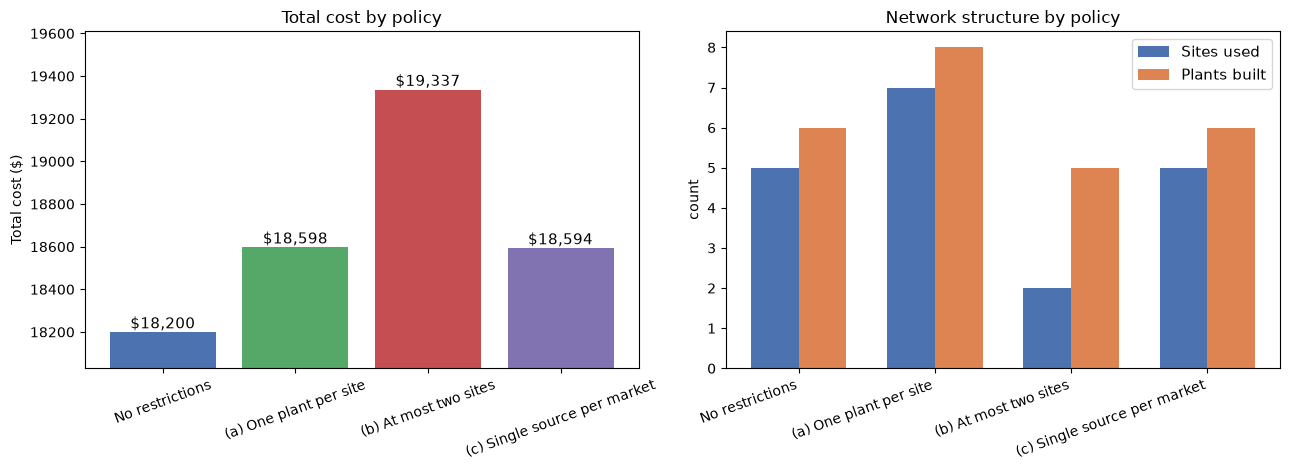

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
order = ["No restrictions", "(a) One plant per site", 
         "(b) At most two sites", "(c) Single source per market"]
costs = comparison.loc[order, "Total cost"]
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]

# Panel 1: Total cost
bars = axes[0].bar(order, costs, color=colors)
pad = (costs.max() - costs.min()) * 0.15
axes[0].set_ylim(costs.min() - pad, costs.max() + pad * 1.6)
for bar, v in zip(bars, costs):
    axes[0].annotate(f"${v:,.0f}", (bar.get_x() + bar.get_width() / 2, v), ha="center", va="bottom", fontsize=11)
axes[0].set_ylabel("Total cost ($)")
axes[0].set_title("Total cost by policy")
axes[0].tick_params(axis="x", rotation=20)

# Panel 2: Network structure
width = 0.35
xpos = np.arange(len(order))
axes[1].bar(xpos - width / 2, comparison.loc[order, "Sites used"], width, label="Sites used", color="#4c72b0")
axes[1].bar(xpos + width / 2, comparison.loc[order, "Plants built"], width, label="Plants built", color="#dd8452")
axes[1].set_xticks(xpos)
axes[1].set_xticklabels(order, rotation=20, ha="right")
axes[1].set_ylabel("count")
axes[1].set_title("Network structure by policy")
axes[1].legend(fontsize=11)

fig.tight_layout()
plt.show()

## Conclusion

Every restriction costs more than the base case, that's expected, since each one adds constraints to an already-optimal solution.

| | Total cost | Premium | Sites used | Plants built |
|---|---:|---:|---:|---:|
| No restrictions | `$18,200` | — | 5 | 6 |
| (a) One plant per site | `$18,598` | `+$398` (2.19%) | 7 | 8 |
| (b) At most two sites | `$19,337` | `+$1,137` (6.25%) | 2 | 5 |
| (c) Single source per market | `$18,594` | `+$394` (2.16%) | 5 | 6 |

- **(a) and (c) cost about the same, but for different reasons.** Both add roughly 2.2%. (a) gets there by building at all seven sites, the most spread-out network of the four. (c) gets there without changing the footprint at all (still 5 sites, 6 plants), it just stops markets from sharing a supplier.
- **(b) is the expensive one, and it's not close.** Capping the network at two sites costs 6.25%, about 3× either of the other restrictions. In this variant, the production + freight cost increases whereas the fixed cost barely changes. Fewer sites means longer hauls, and that's the whole story.
- **Bottom line:** if you need a restriction, (a) or (c) are cheap, about 2.2% either way. Only go with (b) if there's a real reason to consolidate that's worth more than the extra $1,137, since the model is pretty clearly states it's the worst deal of the three.